In [1]:
from pathlib import Path
import pandas as pd
from timesnet_encoder import TimesBlock
from sequences_peaks import SequenceConfig, _load_sequence_dataframe, _load_signal_from_row, _generate_peak_mask, TrainSequence, ValidationSequence
from dataclasses import replace
from utils import setup_gpu

setup_gpu(memory_fraction=1)


2026-04-09 07:42:17.643731: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-09 07:42:17.643765: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-09 07:42:17.644678: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-09 07:42:17.649675: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


gpouıoıraestodf
gpus: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-04-09 07:42:20.441363: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-09 07:42:20.447842: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-09 07:42:20.449737: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [2]:

DATA_FOLDER = Path("/tf/start_training/data/signal/2026-02-11-walking-with-peaks")

# CSV yolları (peaks sütunu içeren yeni dosyaların)
TRAIN_CSV = DATA_FOLDER / "train.csv"
VAL_CSV = DATA_FOLDER / "validation.csv"
TEST_CSV = DATA_FOLDER / "test.csv"

WINDOW_SIZE = 5000
LABEL_NAMES = ['walking']
# Sequence ayarları
config = SequenceConfig(
    csv_path=TRAIN_CSV,
    batch_size=32,
    n_classes=len(LABEL_NAMES), # Örn: 3 sınıf
    window_size=WINDOW_SIZE,
    shuffle=True,
    balance=True
)
train_seq = TrainSequence(config)
val_seq = ValidationSequence(replace(config, csv_path=VAL_CSV))

In [3]:
encoder = TimesBlock.build_encoder_v4()
generator = TimesBlock.build_generator_v4()
discriminator = TimesBlock.build_discriminator_v4()

encoder.summary()
generator.summary()
discriminator.summary()

2026-04-09 07:42:20.504003: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-09 07:42:20.505911: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-09 07:42:20.507714: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Model: "Encoder_V4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 signal_input_only (InputLa  [(None, 5000, 1)]         0         
 yer)                                                            
                                                                 
 conv1d (Conv1D)             (None, 625, 64)           2688      
                                                                 
 batch_normalization (Batch  (None, 625, 64)           256       
 Normalization)                                                  
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 625, 64)           0         
                                                                 
 times_block (TimesBlock)    (None, 625, 64)           74112     
                                                                 
 times_block_1 (TimesBlock)  (None, 625, 64)           7

In [4]:
import tensorflow as tf
# import tf_keras as keras
classifier = tf.keras.models.load_model("/tf/models/clf939.h5")
classifier.trainable = False
WALKING_INDEX = 6

In [5]:
def prepare_for_classifier(fake_signals):
    # 1. Kanal boyutunu kaldır: (Batch, 5000, 1) -> (Batch, 5000)
    s = tf.squeeze(fake_signals, axis=-1)
    # Normalizasyon Dönüşümü: [-1, 1] -> [0, 1]
    s_01 = (s + 1.0) / 2.0
    
    # [1, 4] -> Batch boyutunu 1 kez, zaman boyutunu 4 kez tekrarla
    s_20k = tf.tile(s_01, [1, 4])
    
    return s_20k

In [6]:
# Optimizer'lar
enc_gen_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.5, clipnorm=1.0)
disc_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.5, clipnorm=1.0)

# Kayıp fonksiyonları
bce = tf.keras.losses.BinaryCrossentropy()
mse = tf.keras.losses.MeanSquaredError()

# coefficients

alpha = 1.0 
beta = 0.5

In [7]:
import tensorflow as tf

# Sinyalin maksimum mutlak genliği (Örn: Sinyal -250 ile +250 arası değişiyorsa)
GLOBAL_MAX_AMP = 250.0 

@tf.function
def train_step(real_signals, peak_masks):
    batch_size = tf.shape(real_signals)[0]
    WALKING_INDEX = 6
    
    # 1. [-1, 1] NORMALİZASYONU (tanh uyumlu)
    # Gerçek sinyali GLOBAL_MAX_AMP değerine bölerek [-1, 1] aralığına çekiyoruz.
    # Eğer sinyal -200 ise -0.8 olur, 250 ise 1.0 olur.
    real_signals_normalized = real_signals / GLOBAL_MAX_AMP

    # --- DISCRIMINATOR EĞİTİMİ ---
    with tf.GradientTape() as disc_tape:
        z = encoder(real_signals_normalized, training=False)
        fake_signals = generator([z, peak_masks], training=False)
        
        pred_real = discriminator(real_signals_normalized, training=True)
        pred_fake = discriminator(fake_signals, training=True)
        
        d_loss = bce(tf.ones_like(pred_real), pred_real) + \
                 bce(tf.zeros_like(pred_fake), pred_fake)

    grads_disc = disc_tape.gradient(d_loss, discriminator.trainable_variables)
    disc_optimizer.apply_gradients(zip(grads_disc, discriminator.trainable_variables))

    # --- ENCODER & GENERATOR EĞİTİMİ ---
    with tf.GradientTape() as gen_tape:
        z = encoder(real_signals_normalized, training=True)
        fake_signals = generator([z, peak_masks], training=True) 
        
        # L_rec: 1. Adversarial Bileşen
        pred_fake_disc = discriminator(fake_signals, training=False)
        l_adv = bce(tf.ones_like(pred_fake_disc), pred_fake_disc)
        
        # -------------------------------------------------------------
        # PEAK-WEIGHTED MSE (Koşulu Zorunlu Kılma)
        # -------------------------------------------------------------
        sq_error = tf.square(real_signals_normalized - fake_signals)
        
        # Peak olan yerlere ekstra ağırlık (ceza) ver (Örn: 20 kat ceza)
        peak_weight = 1.0 + (20.0 * peak_masks) 
        
        l_mse_weighted = tf.reduce_mean(sq_error * peak_weight)
        # -------------------------------------------------------------
        
        # L_rec: 2. Ağırlıklı MSE Bileşeni (Ağırlığı 50.0 yaptık ki şekle odaklansın)
        L_rec = l_adv + (50.0 * l_mse_weighted) 
        
        # L_cls: Classifier Onayı
        # DİKKAT: fake_signals [-1, 1] aralığında olduğu için 
        # prepare_for_classifier içinde (x+1)/2 işlemi yaparak 
        # classifier'a [0, 1] aralığında göndermeliyiz.
        fake_20k = prepare_for_classifier(fake_signals) 
        cls_predictions = classifier(fake_20k, training=False)
        
        walking_scores = cls_predictions[:, WALKING_INDEX]
        L_cls = bce(tf.ones((batch_size,)), walking_scores)
        
        total_gen_loss = (1.0 * L_rec) + (0.01 * L_cls)

    var_list = encoder.trainable_variables + generator.trainable_variables
    grads_gen = gen_tape.gradient(total_gen_loss, var_list)
    enc_gen_optimizer.apply_gradients(zip(grads_gen, var_list))
    
    return d_loss, total_gen_loss, L_rec, L_cls

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_epoch_results(epoch, encoder, generator, train_seq):
    # 1. Eğitim setinden rastgele bir batch al
    batch_idx = np.random.randint(0, len(train_seq))
    batch_data, _ = train_seq[batch_idx]
    
    # 2. Gerçek verileri ayır (Sadece ilk örneği görselleştirelim)
    real_sig = batch_data[0:1, :, 0:1] # (1, 5000, 1)
    peak_mask = batch_data[0:1, :, 1:2] # (1, 5000, 1) - Bu bizim "Condition"ımız

    # 3. Modelden üretim yap
    # Encoder sinyali anlar, Generator peak maskesini kullanarak yeniden çizer
    embedding = encoder(real_sig, training=False)
    fake_sig = generator([embedding, peak_mask], training=False)
    fake_sig = fake_sig.numpy() * GLOBAL_MAX_AMP
    real_sig = real_sig * GLOBAL_MAX_AMP

    # 4. Görselleştirme
    plt.figure(figsize=(18, 10))
    
    # Üst Panel: Gerçek Sinyal ve Peak Maskesi
    plt.subplot(2, 1, 1)
    plt.plot(real_sig[0, :, 0], color='gray', alpha=0.6, label='Orijinal DAS Sinyali (Ground Truth)')
    plt.fill_between(range(5000), peak_mask[0, :, 0] * np.max(real_sig), 
                     color='red', alpha=0.2, label='Gerçek Peak Iskeleti (Input to Gen)')
    plt.title(f"Epoch {epoch+1}: Orijinal Veri ve Peak Referansı")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    
    # Alt Panel: Üretilen Sinyal ve Aynı Peak Maskesi
    plt.subplot(2, 1, 2)
    plt.plot(fake_sig[0, :, 0], color='dodgerblue', linewidth=1.2, label='AI Tarafından Üretilen Sinyal')
    plt.fill_between(range(5000), peak_mask[0, :, 0] * np.max(fake_sig), 
                     color='red', alpha=0.2, label='Aynı Peak Iskeleti (Reconstruction)')
    plt.title(f"Epoch {epoch+1}: Jeneratörün Peak'lere Göre Çizdiği Sinyal")
    plt.xlabel("Sample Index (5000)")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

--- EPOCH 1 BAŞLADI ---
Veri setinden ilk batch çekiliyor...

[BİLGİ] İlk step train_step'e gönderildi. TensorFlow grafiği derliyor (Tracing).
Bu işlem sistemine bağlı olarak 1-5 dakika sürebilir. Lütfen bekleyin...



2026-04-09 07:42:26.629682: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
2026-04-09 07:42:28.228398: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f20cd284ab0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-09 07:42:28.228419: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-04-09 07:42:28.231816: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775720548.284807   19192 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Epoch 1 | Step 366/367 | D_Loss: 1.1324 | G_Total: 3.6996
Epoch 1 Özet | D_Loss: 1.1615 | G_Total: 39.02 | Rec: 3.68 | Cls: 1.34
--- EPOCH 2 BAŞLADI ---
Epoch 2 | Step 366/367 | D_Loss: 0.9458 | G_Total: 3.7333
Epoch 2 Özet | D_Loss: 0.9538 | G_Total: 38.73 | Rec: 3.71 | Cls: 2.26
--- EPOCH 3 BAŞLADI ---
Epoch 3 | Step 366/367 | D_Loss: 0.8086 | G_Total: 3.6459
Epoch 3 Özet | D_Loss: 0.6926 | G_Total: 38.67 | Rec: 3.62 | Cls: 1.36
--- EPOCH 4 BAŞLADI ---
Epoch 4 | Step 366/367 | D_Loss: 0.9229 | G_Total: 5.2044
Epoch 4 Özet | D_Loss: 0.7687 | G_Total: 38.92 | Rec: 5.19 | Cls: 0.81
--- EPOCH 5 BAŞLADI ---
Epoch 5 | Step 366/367 | D_Loss: 0.9183 | G_Total: 3.5573
Epoch 5 Özet | D_Loss: 0.7811 | G_Total: 38.97 | Rec: 3.54 | Cls: 0.82


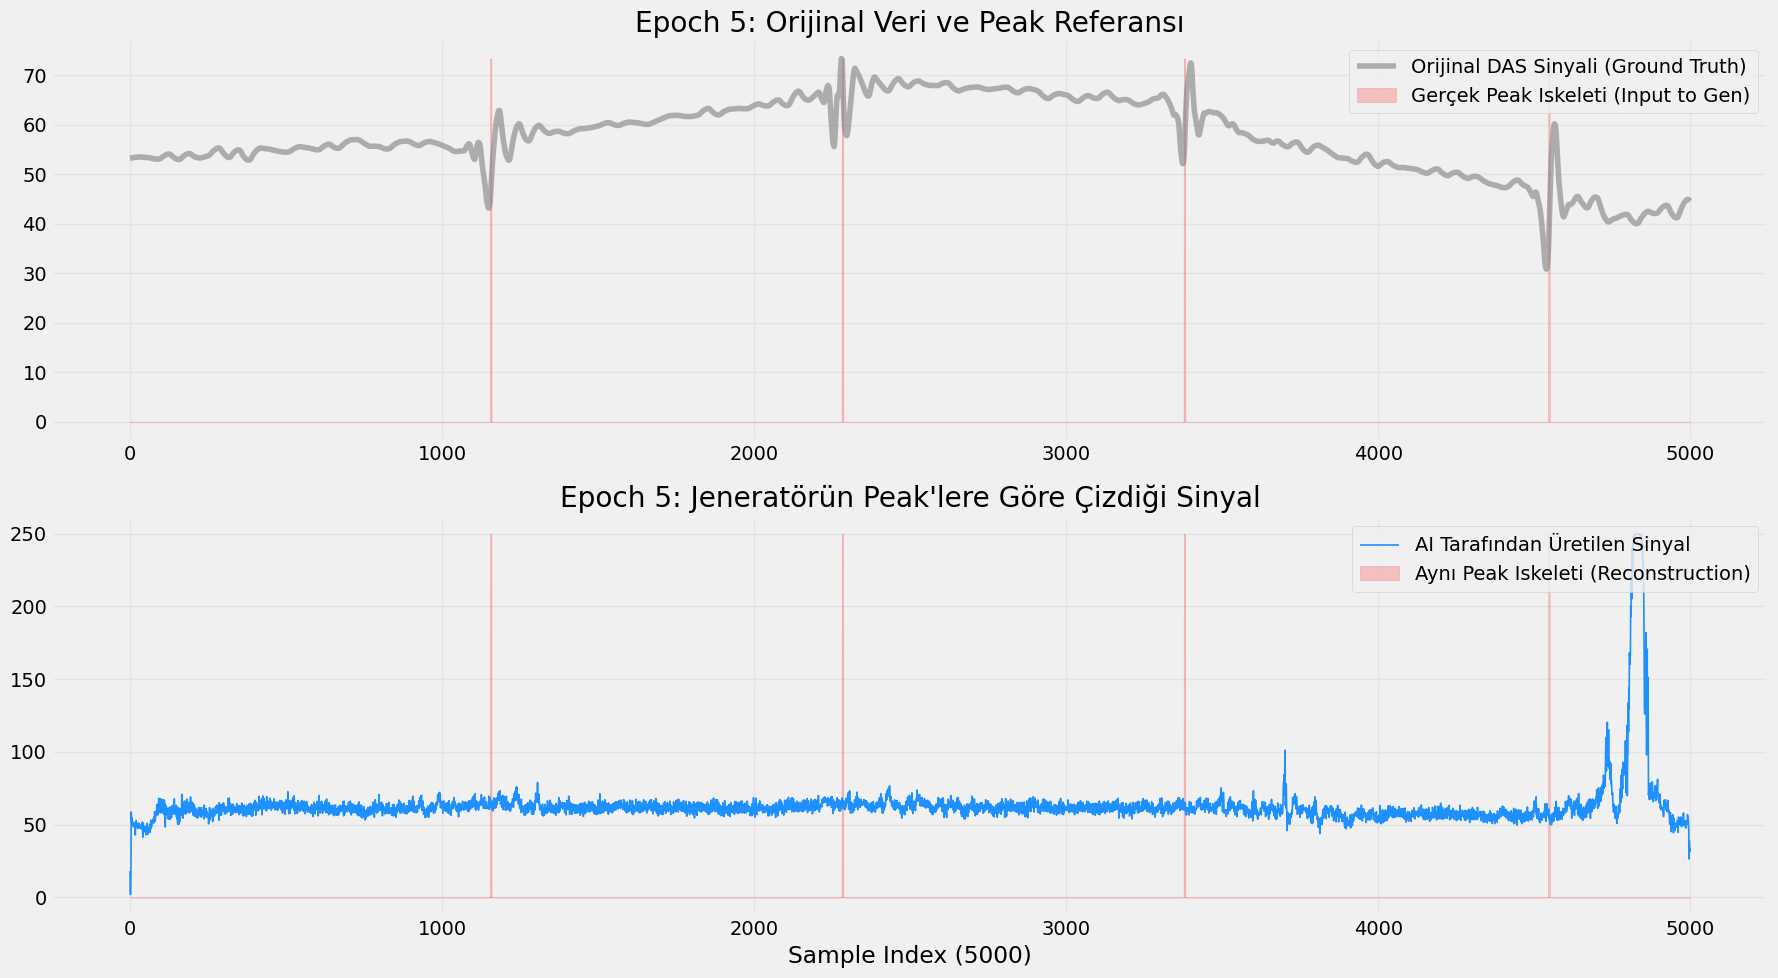

--- EPOCH 6 BAŞLADI ---
Epoch 6 | Step 366/367 | D_Loss: 0.9545 | G_Total: 4.2711
Epoch 6 Özet | D_Loss: 0.8029 | G_Total: 39.05 | Rec: 4.25 | Cls: 1.28
--- EPOCH 7 BAŞLADI ---
Epoch 7 | Step 366/367 | D_Loss: 1.0000 | G_Total: 3.6005
Epoch 7 Özet | D_Loss: 0.9320 | G_Total: 39.11 | Rec: 3.59 | Cls: 1.42
--- EPOCH 8 BAŞLADI ---
Epoch 8 | Step 366/367 | D_Loss: 1.0474 | G_Total: 4.2608
Epoch 8 Özet | D_Loss: 0.9466 | G_Total: 38.99 | Rec: 4.24 | Cls: 1.16
--- EPOCH 9 BAŞLADI ---
Epoch 9 | Step 366/367 | D_Loss: 0.8857 | G_Total: 3.7410
Epoch 9 Özet | D_Loss: 0.9193 | G_Total: 38.89 | Rec: 3.73 | Cls: 1.08
--- EPOCH 10 BAŞLADI ---
Epoch 10 | Step 366/367 | D_Loss: 0.9774 | G_Total: 3.4147
Epoch 10 Özet | D_Loss: 0.9357 | G_Total: 38.89 | Rec: 3.40 | Cls: 0.78


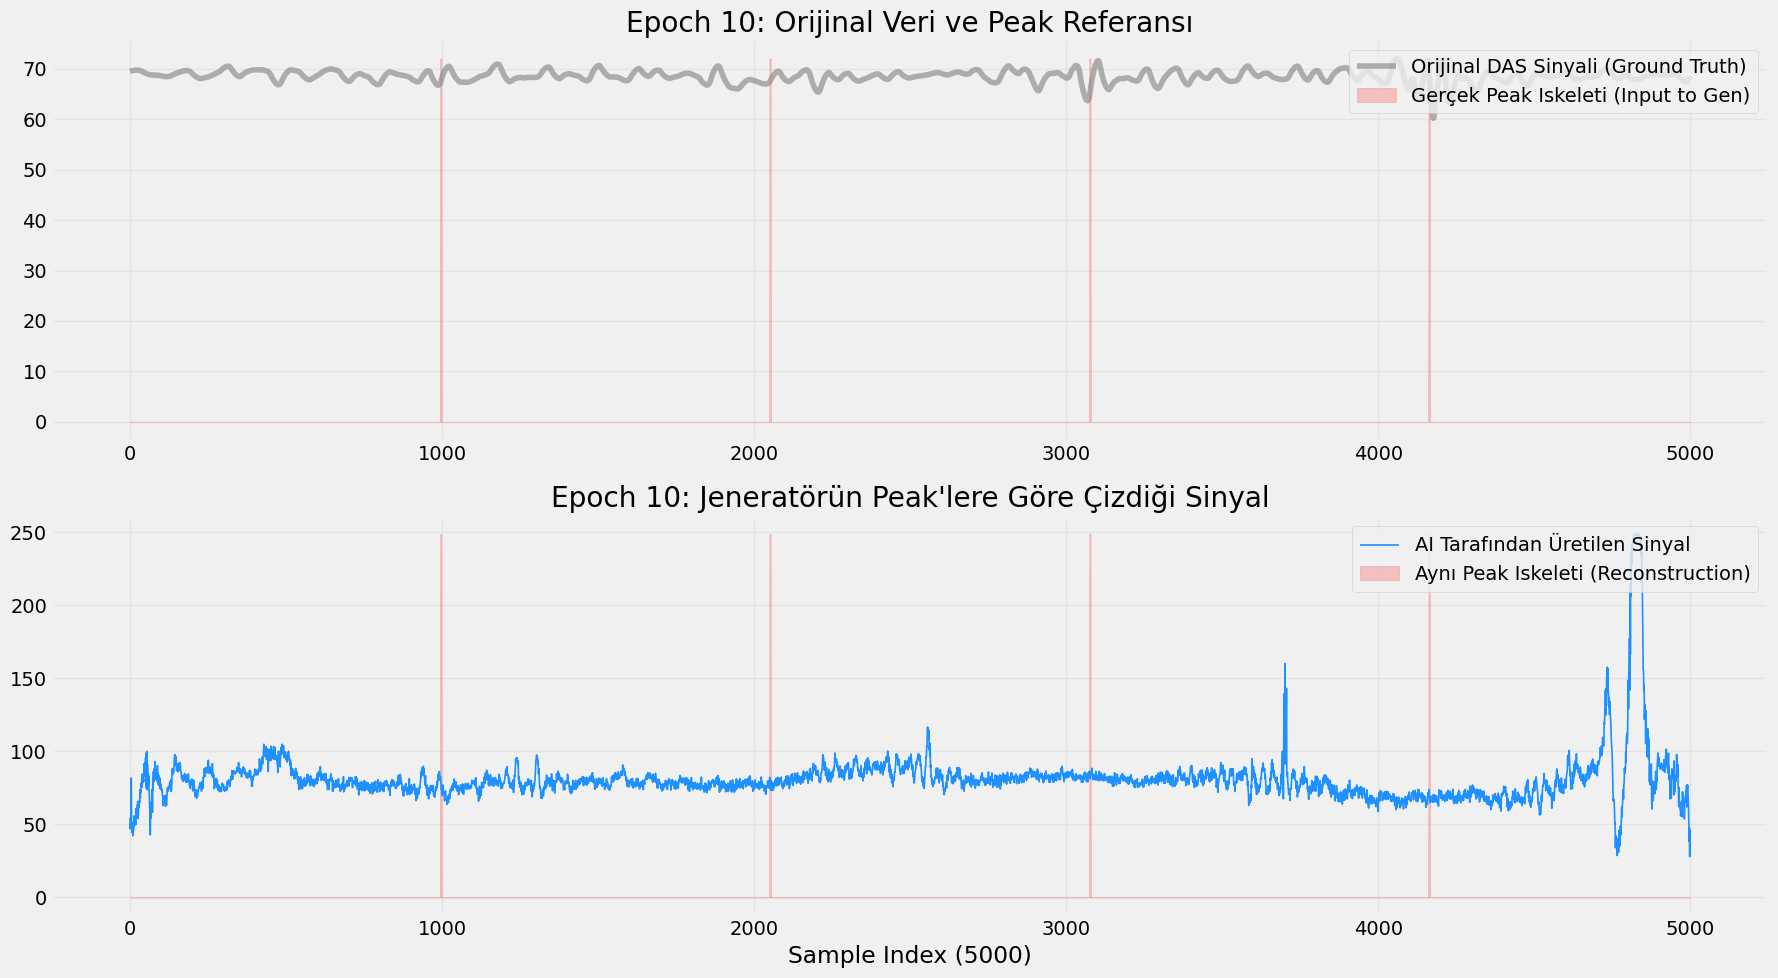

--- EPOCH 11 BAŞLADI ---
Epoch 11 | Step 366/367 | D_Loss: 1.4480 | G_Total: 3.5666
Epoch 11 Özet | D_Loss: 1.0060 | G_Total: 38.88 | Rec: 3.55 | Cls: 0.83
--- EPOCH 12 BAŞLADI ---
Epoch 12 | Step 366/367 | D_Loss: 1.4392 | G_Total: 3.5051
Epoch 12 Özet | D_Loss: 1.0285 | G_Total: 38.77 | Rec: 3.49 | Cls: 0.85
--- EPOCH 13 BAŞLADI ---
Epoch 13 | Step 366/367 | D_Loss: 1.3872 | G_Total: 3.8532
Epoch 13 Özet | D_Loss: 1.0175 | G_Total: 38.84 | Rec: 3.84 | Cls: 1.02
--- EPOCH 14 BAŞLADI ---
Epoch 14 | Step 366/367 | D_Loss: 0.9085 | G_Total: 4.2888
Epoch 14 Özet | D_Loss: 1.0011 | G_Total: 38.75 | Rec: 4.27 | Cls: 1.53
--- EPOCH 15 BAŞLADI ---
Epoch 15 | Step 366/367 | D_Loss: 1.0135 | G_Total: 4.3230
Epoch 15 Özet | D_Loss: 0.9183 | G_Total: 39.26 | Rec: 4.31 | Cls: 0.89


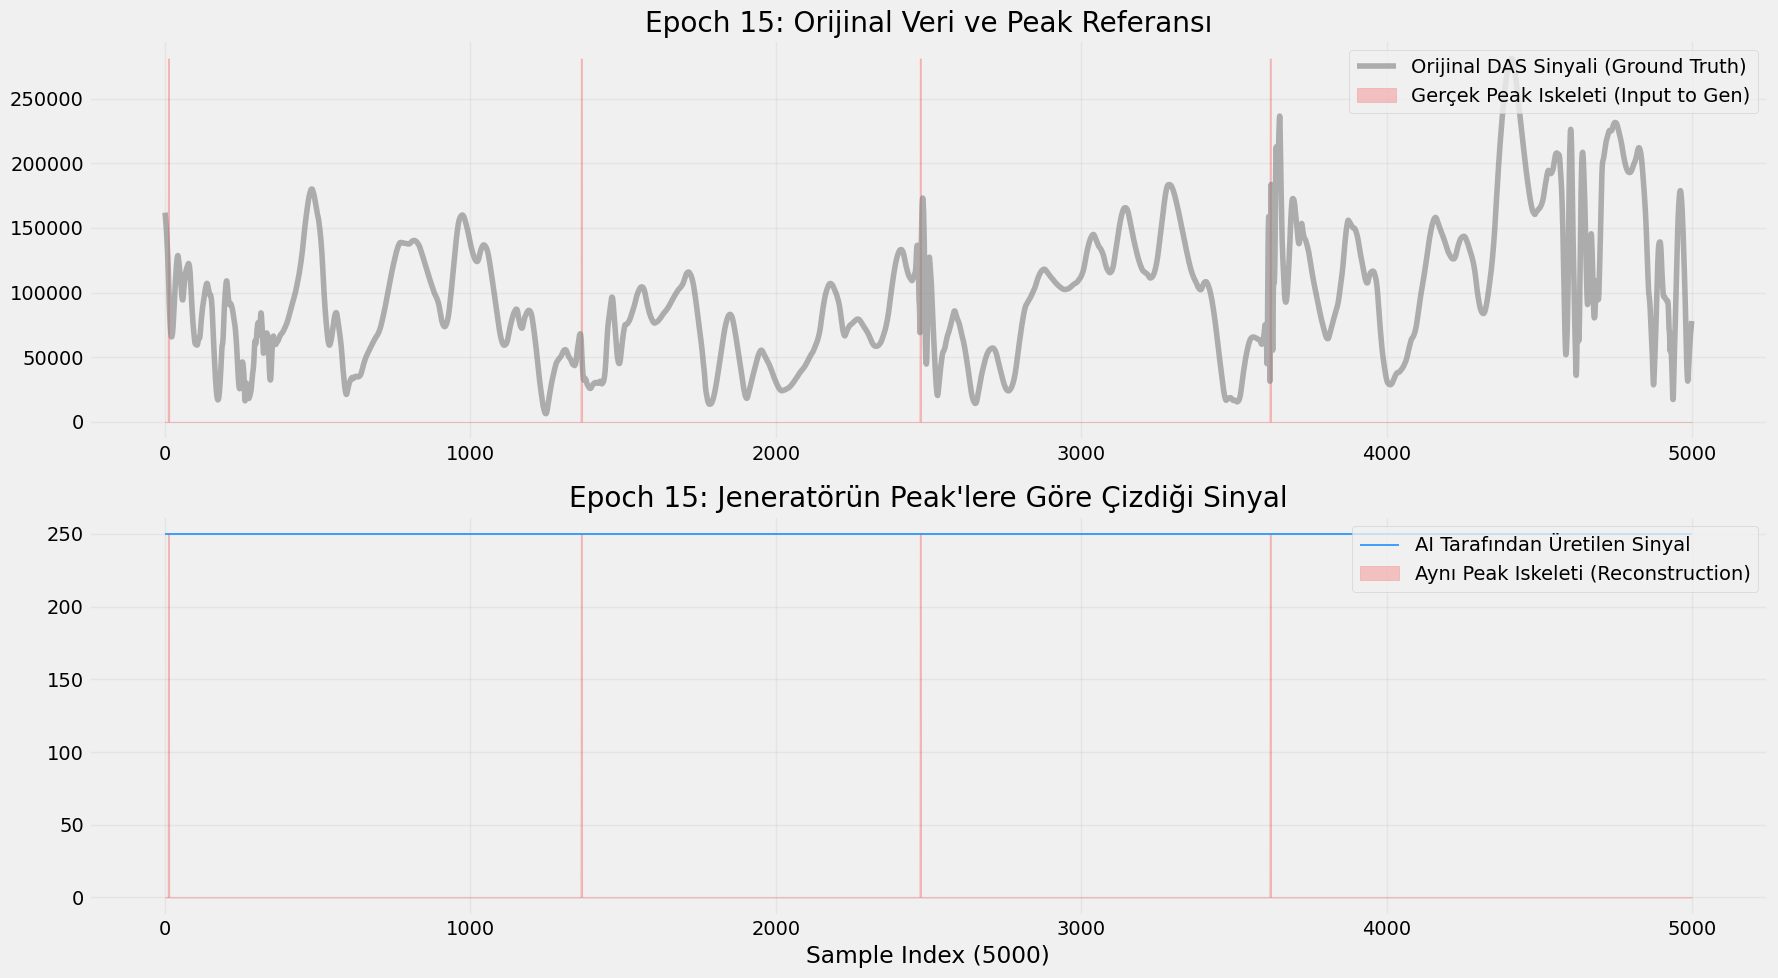

--- EPOCH 16 BAŞLADI ---
Epoch 16 | Step 366/367 | D_Loss: 0.9933 | G_Total: 3.8838
Epoch 16 Özet | D_Loss: 0.9291 | G_Total: 38.73 | Rec: 3.87 | Cls: 1.13
--- EPOCH 17 BAŞLADI ---
Epoch 17 | Step 366/367 | D_Loss: 1.4057 | G_Total: 3.4839
Epoch 17 Özet | D_Loss: 0.8193 | G_Total: 38.61 | Rec: 3.47 | Cls: 1.08
--- EPOCH 18 BAŞLADI ---
Epoch 18 | Step 366/367 | D_Loss: 0.5982 | G_Total: 3.2299
Epoch 18 Özet | D_Loss: 0.6894 | G_Total: 38.55 | Rec: 3.20 | Cls: 1.88
--- EPOCH 19 BAŞLADI ---
Epoch 19 | Step 366/367 | D_Loss: 0.5276 | G_Total: 3.2413
Epoch 19 Özet | D_Loss: 0.6731 | G_Total: 38.65 | Rec: 3.22 | Cls: 1.35
--- EPOCH 20 BAŞLADI ---
Epoch 20 | Step 366/367 | D_Loss: 1.3968 | G_Total: 3.3749
Epoch 20 Özet | D_Loss: 0.7060 | G_Total: 38.72 | Rec: 3.36 | Cls: 1.17


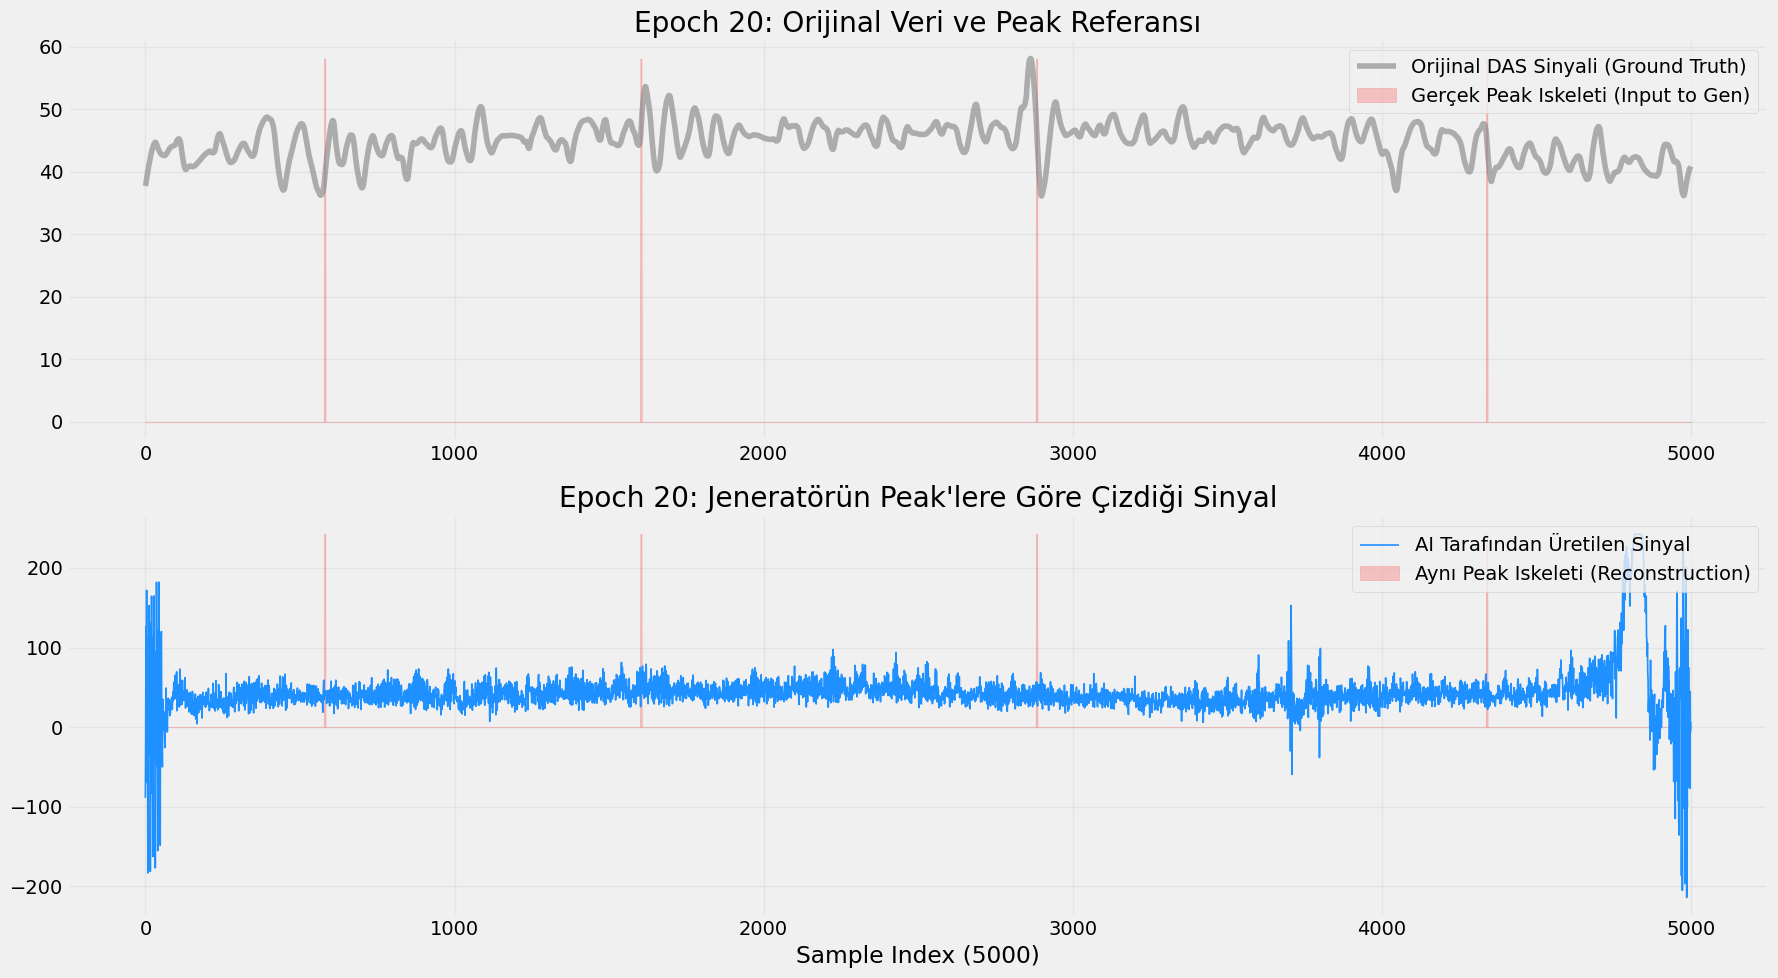

--- EPOCH 21 BAŞLADI ---
Epoch 21 | Step 366/367 | D_Loss: 1.4723 | G_Total: 3.6297
Epoch 21 Özet | D_Loss: 0.6148 | G_Total: 38.81 | Rec: 3.61 | Cls: 1.33
--- EPOCH 22 BAŞLADI ---
Epoch 22 | Step 366/367 | D_Loss: 0.5295 | G_Total: 3.6217
Epoch 22 Özet | D_Loss: 0.6746 | G_Total: 39.06 | Rec: 3.60 | Cls: 1.90
--- EPOCH 23 BAŞLADI ---
Epoch 23 | Step 366/367 | D_Loss: 1.2419 | G_Total: 4.6615
Epoch 23 Özet | D_Loss: 0.6432 | G_Total: 39.38 | Rec: 4.65 | Cls: 1.15
--- EPOCH 24 BAŞLADI ---
Epoch 24 | Step 366/367 | D_Loss: 0.6250 | G_Total: 3.9732
Epoch 24 Özet | D_Loss: 0.6057 | G_Total: 39.67 | Rec: 3.96 | Cls: 1.32
--- EPOCH 25 BAŞLADI ---
Epoch 25 | Step 366/367 | D_Loss: 1.2571 | G_Total: 3.5729
Epoch 25 Özet | D_Loss: 0.5808 | G_Total: 39.89 | Rec: 3.56 | Cls: 0.48


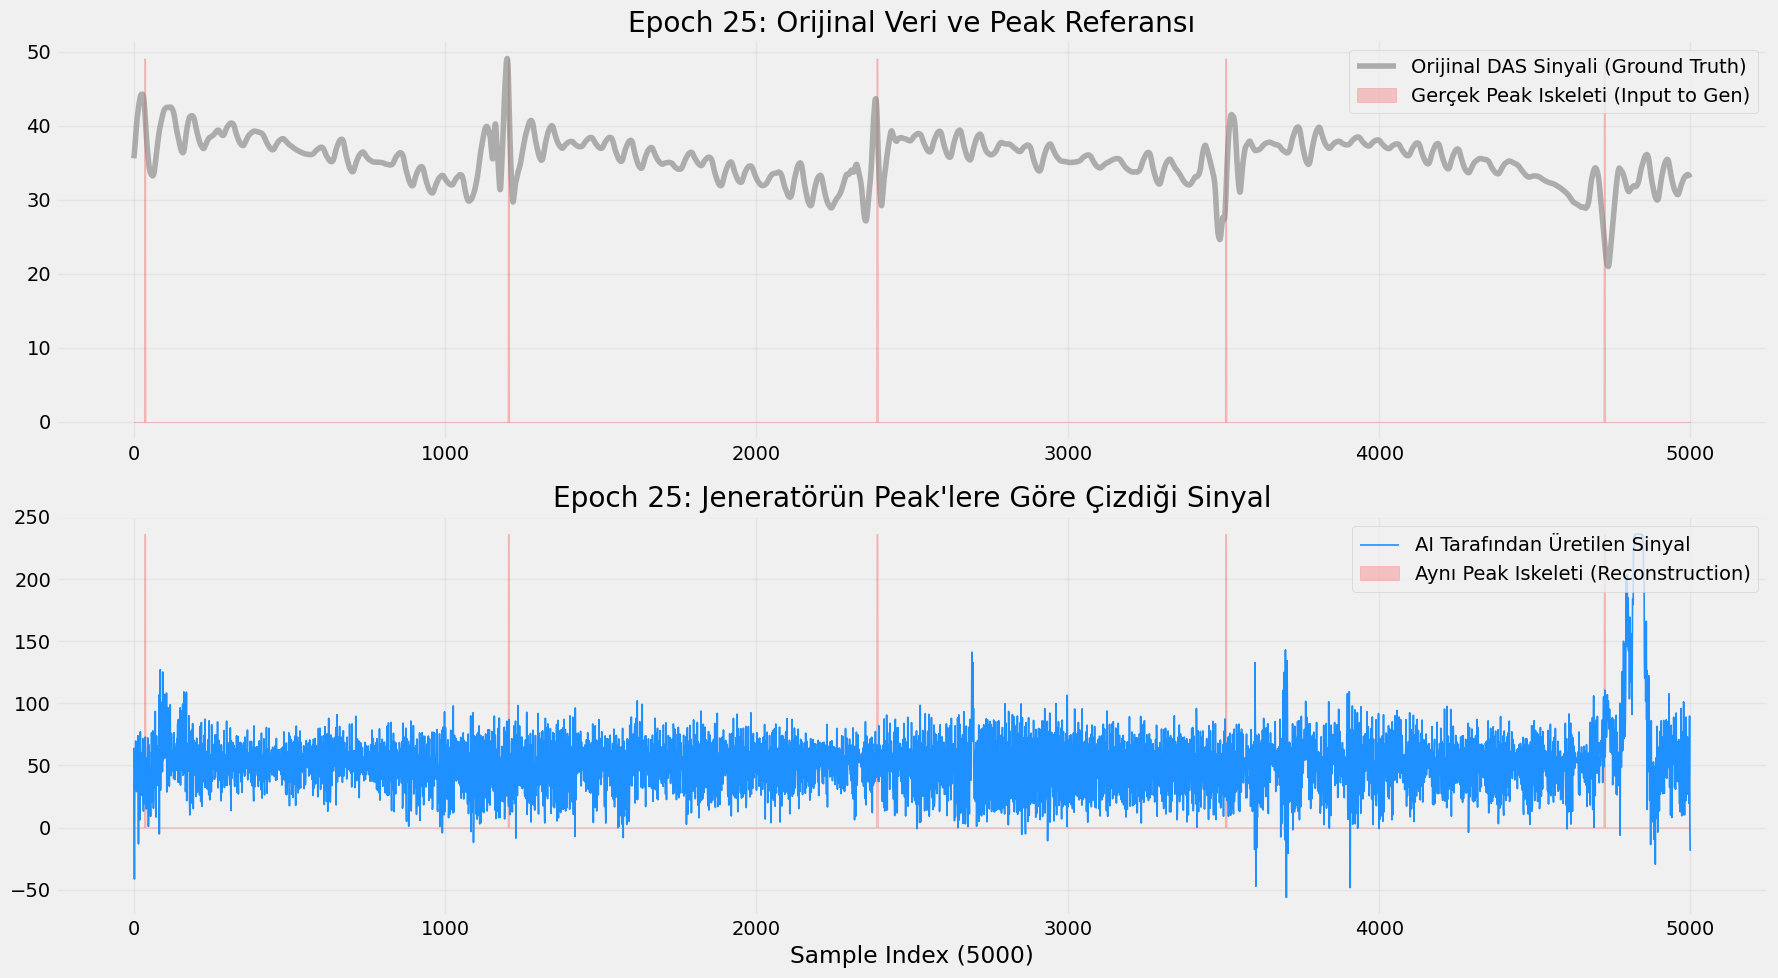

--- EPOCH 26 BAŞLADI ---
Epoch 26 | Step 366/367 | D_Loss: 0.5729 | G_Total: 7.7887
Epoch 26 Özet | D_Loss: 0.5280 | G_Total: 39.99 | Rec: 7.77 | Cls: 0.82
--- EPOCH 27 BAŞLADI ---
Epoch 27 | Step 366/367 | D_Loss: 0.5066 | G_Total: 3.7723
Epoch 27 Özet | D_Loss: 0.5788 | G_Total: 40.71 | Rec: 3.76 | Cls: 1.69
--- EPOCH 28 BAŞLADI ---
Epoch 28 | Step 366/367 | D_Loss: 0.3667 | G_Total: 79.018
Epoch 28 Özet | D_Loss: 0.3561 | G_Total: 70.84 | Rec: 78.94 | Cls: 7.28
--- EPOCH 29 BAŞLADI ---
Epoch 29 | Step 366/367 | D_Loss: 0.4333 | G_Total: 3.9171
Epoch 29 Özet | D_Loss: 0.3021 | G_Total: 46.11 | Rec: 3.79 | Cls: 12.34
--- EPOCH 30 BAŞLADI ---
Epoch 30 | Step 366/367 | D_Loss: 0.9741 | G_Total: 4.6550
Epoch 30 Özet | D_Loss: 0.4080 | G_Total: 41.67 | Rec: 4.53 | Cls: 11.92


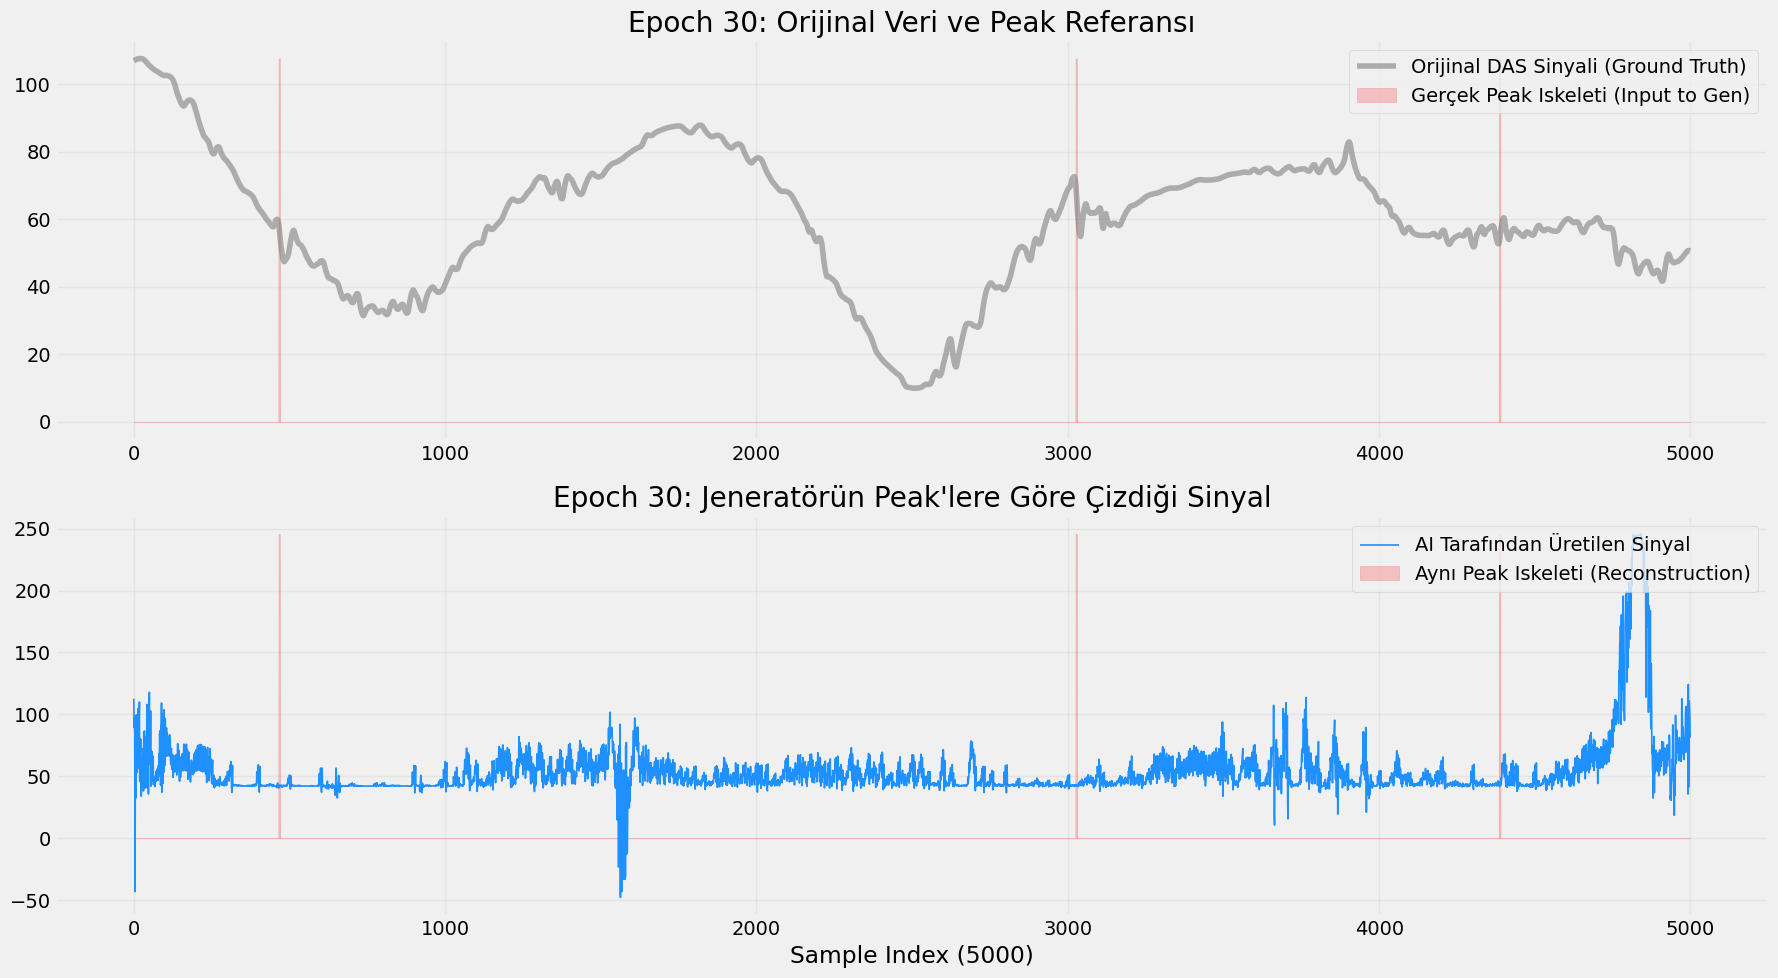

--- EPOCH 31 BAŞLADI ---
Epoch 31 | Step 366/367 | D_Loss: 0.9050 | G_Total: 4.5200
Epoch 31 Özet | D_Loss: 0.5024 | G_Total: 40.43 | Rec: 4.51 | Cls: 1.37
--- EPOCH 32 BAŞLADI ---
Epoch 32 | Step 366/367 | D_Loss: 0.5570 | G_Total: 3.5460
Epoch 32 Özet | D_Loss: 0.5782 | G_Total: 40.05 | Rec: 3.52 | Cls: 1.78
--- EPOCH 33 BAŞLADI ---
Epoch 33 | Step 366/367 | D_Loss: 0.5424 | G_Total: 4.9506
Epoch 33 Özet | D_Loss: 0.5283 | G_Total: 40.22 | Rec: 4.90 | Cls: 4.44
--- EPOCH 34 BAŞLADI ---
Epoch 34 | Step 366/367 | D_Loss: 0.4710 | G_Total: 13.438
Epoch 34 Özet | D_Loss: 0.4777 | G_Total: 41.03 | Rec: 13.42 | Cls: 0.79
--- EPOCH 35 BAŞLADI ---
Epoch 35 | Step 366/367 | D_Loss: 0.4232 | G_Total: 12.776
Epoch 35 Özet | D_Loss: 0.3808 | G_Total: 41.15 | Rec: 12.76 | Cls: 1.18


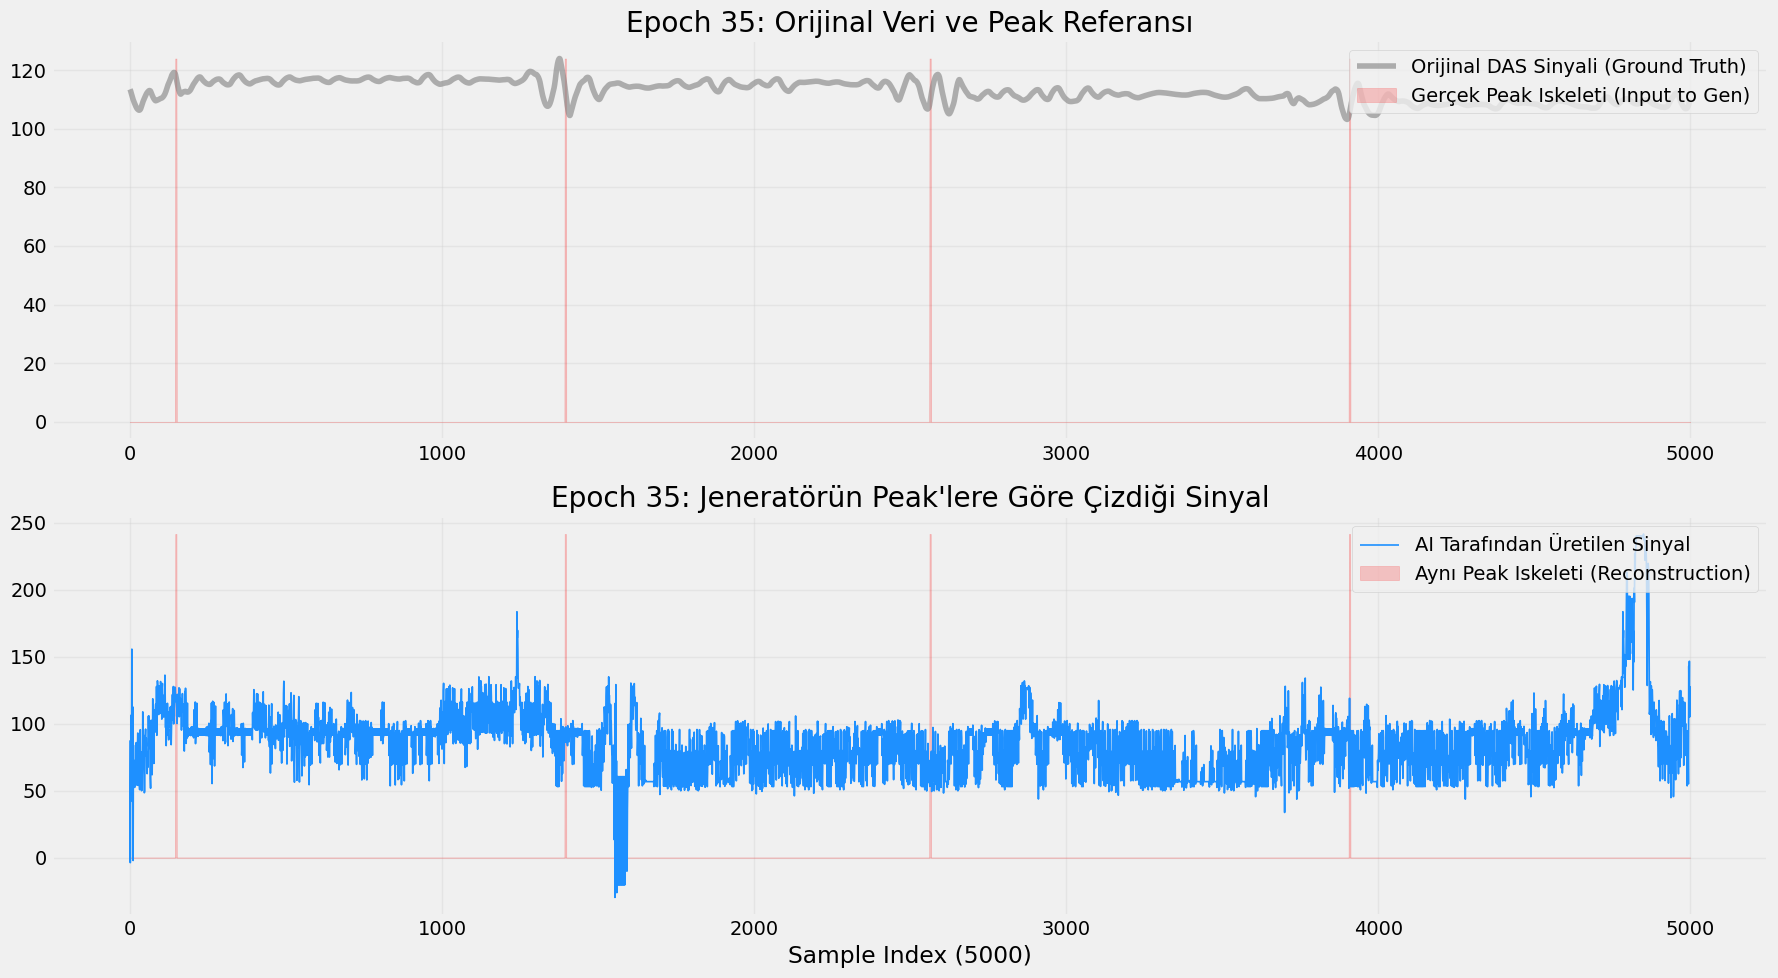

--- EPOCH 36 BAŞLADI ---
Epoch 36 | Step 366/367 | D_Loss: 0.4172 | G_Total: 3.1030
Epoch 36 Özet | D_Loss: 0.3663 | G_Total: 42.21 | Rec: 3.09 | Cls: 0.46
--- EPOCH 37 BAŞLADI ---
Epoch 37 | Step 366/367 | D_Loss: 0.4453 | G_Total: 4.4467
Epoch 37 Özet | D_Loss: 0.3944 | G_Total: 43.13 | Rec: 4.40 | Cls: 4.60
--- EPOCH 38 BAŞLADI ---
Epoch 38 | Step 366/367 | D_Loss: 0.2093 | G_Total: 43.075
Epoch 38 Özet | D_Loss: 0.2825 | G_Total: 50.88 | Rec: 42.93 | Cls: 13.57
--- EPOCH 39 BAŞLADI ---
Epoch 39 | Step 366/367 | D_Loss: 0.2178 | G_Total: 69.679
Epoch 39 Özet | D_Loss: 0.2244 | G_Total: 58.60 | Rec: 69.52 | Cls: 14.22
--- EPOCH 40 BAŞLADI ---
Epoch 40 | Step 366/367 | D_Loss: 0.3071 | G_Total: 37.782
Epoch 40 Özet | D_Loss: 0.2479 | G_Total: 56.53 | Rec: 37.63 | Cls: 14.63


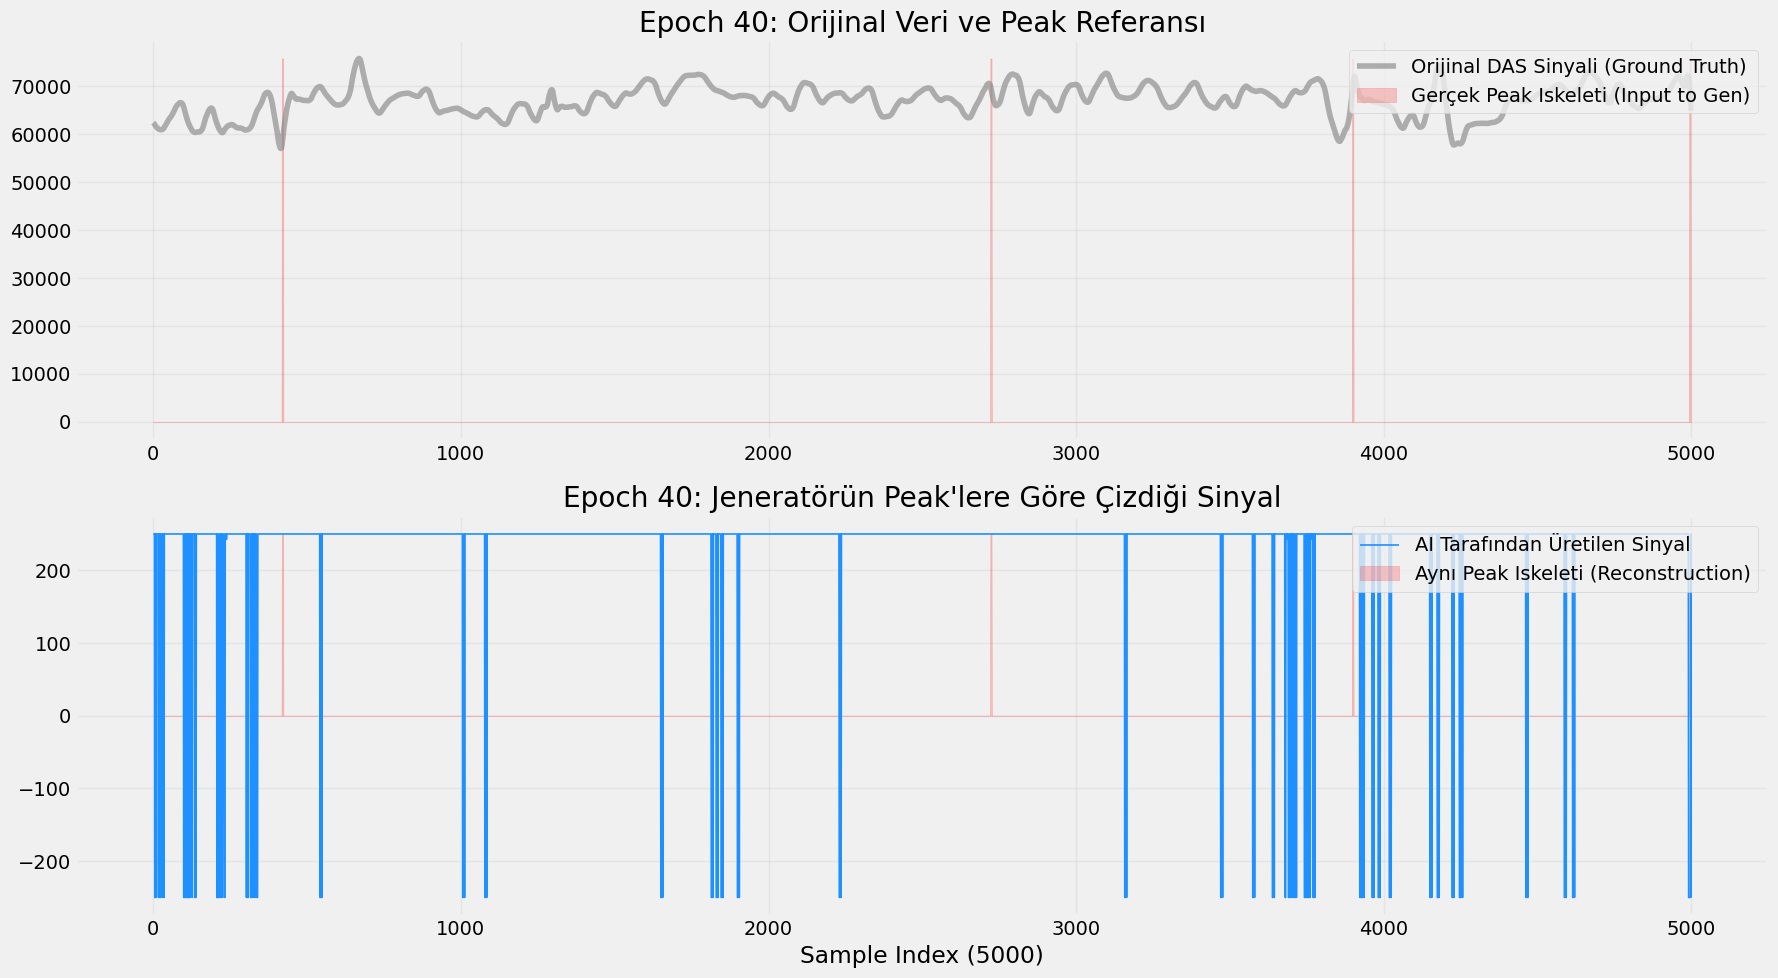

--- EPOCH 41 BAŞLADI ---
Epoch 41 | Step 366/367 | D_Loss: 0.2656 | G_Total: 72.854
Epoch 41 Özet | D_Loss: 0.2228 | G_Total: 55.04 | Rec: 72.71 | Cls: 14.22
--- EPOCH 42 BAŞLADI ---
Epoch 42 | Step 366/367 | D_Loss: 0.3084 | G_Total: 49.086
Epoch 42 Özet | D_Loss: 0.2059 | G_Total: 54.87 | Rec: 48.95 | Cls: 13.21
--- EPOCH 43 BAŞLADI ---
Epoch 43 | Step 366/367 | D_Loss: 0.2861 | G_Total: 9.2927
Epoch 43 Özet | D_Loss: 0.2071 | G_Total: 58.06 | Rec: 9.17 | Cls: 11.98
--- EPOCH 44 BAŞLADI ---
Epoch 44 | Step 366/367 | D_Loss: 0.2989 | G_Total: 18.830
Epoch 44 Özet | D_Loss: 0.2031 | G_Total: 55.13 | Rec: 18.70 | Cls: 13.04
--- EPOCH 45 BAŞLADI ---
Epoch 45 | Step 366/367 | D_Loss: 0.1380 | G_Total: 10.633
Epoch 45 Özet | D_Loss: 0.0971 | G_Total: 71.16 | Rec: 10.48 | Cls: 15.42


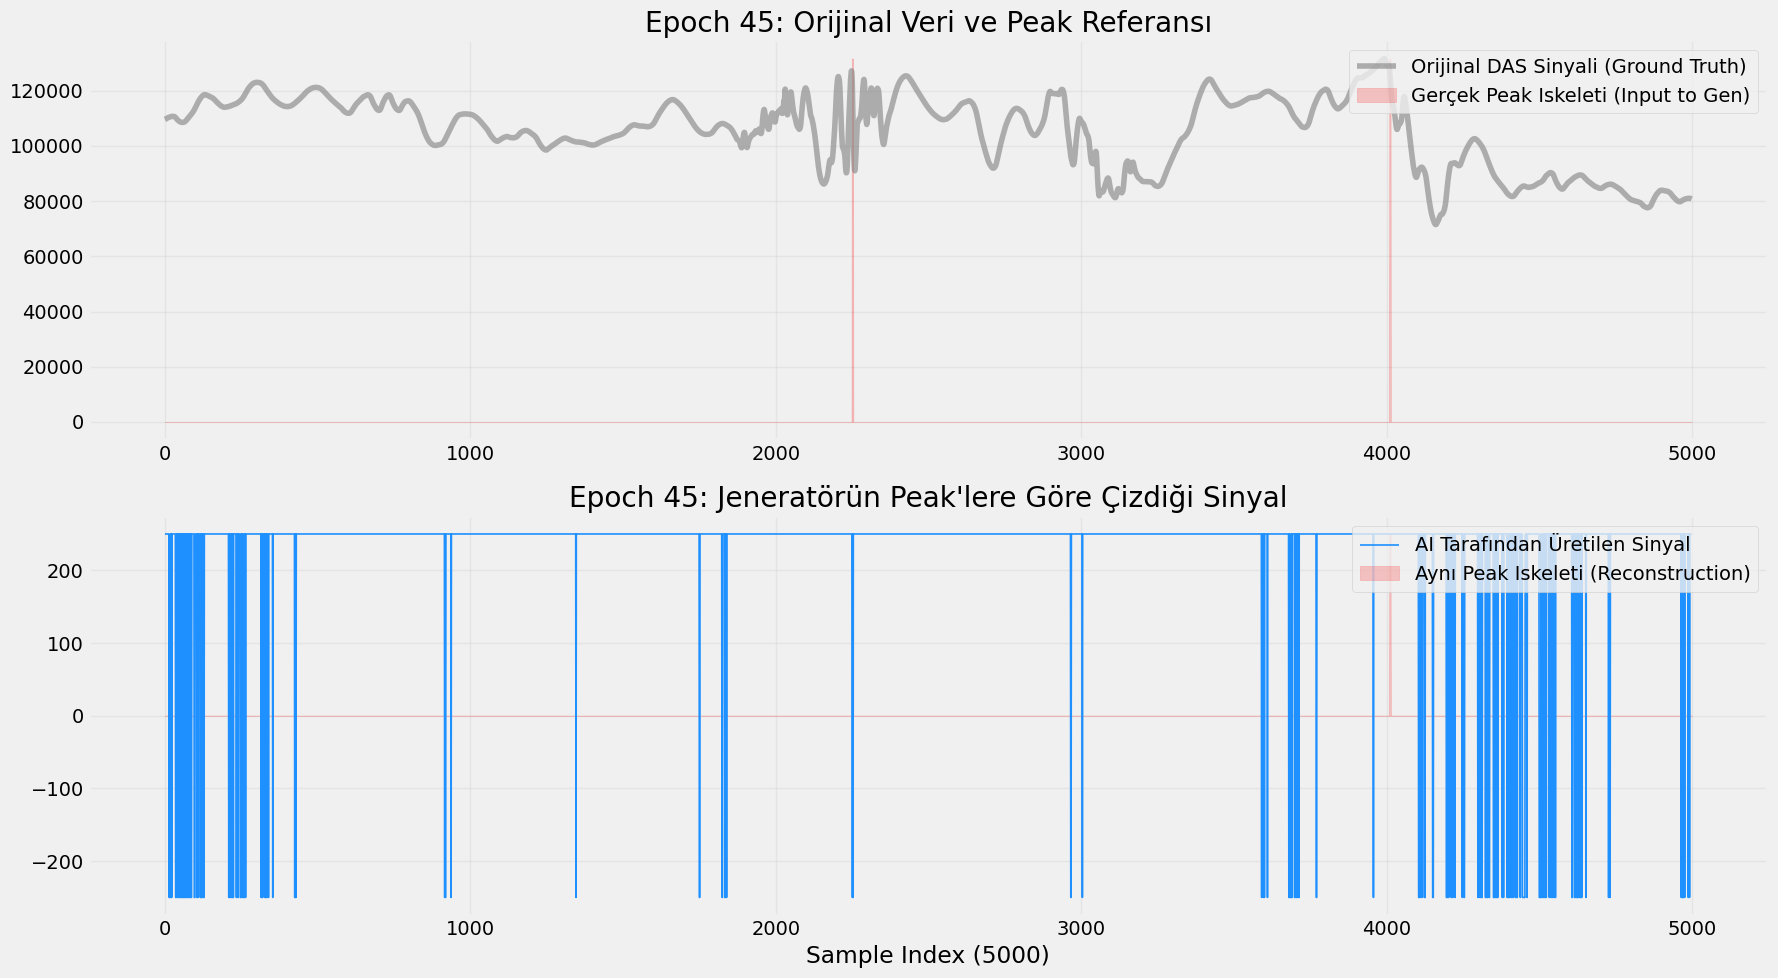

--- EPOCH 46 BAŞLADI ---
Epoch 46 | Step 366/367 | D_Loss: 0.4875 | G_Total: 25.218
Epoch 46 Özet | D_Loss: 0.1125 | G_Total: 60.93 | Rec: 25.09 | Cls: 11.44
--- EPOCH 47 BAŞLADI ---
Epoch 47 | Step 366/367 | D_Loss: 0.3596 | G_Total: 7.6216
Epoch 47 Özet | D_Loss: 0.2163 | G_Total: 50.98 | Rec: 7.50 | Cls: 11.97
--- EPOCH 48 BAŞLADI ---
Epoch 48 | Step 366/367 | D_Loss: 0.3491 | G_Total: 12.524
Epoch 48 Özet | D_Loss: 0.2217 | G_Total: 57.83 | Rec: 12.39 | Cls: 12.63
--- EPOCH 49 BAŞLADI ---
Epoch 49 | Step 366/367 | D_Loss: 0.2704 | G_Total: 46.150
Epoch 49 Özet | D_Loss: 0.2039 | G_Total: 59.70 | Rec: 46.00 | Cls: 14.66
--- EPOCH 50 BAŞLADI ---
Epoch 50 | Step 366/367 | D_Loss: nan | G_Total: nannan652
Epoch 50 Özet | D_Loss: nan | G_Total: nan | Rec: nan | Cls: nan


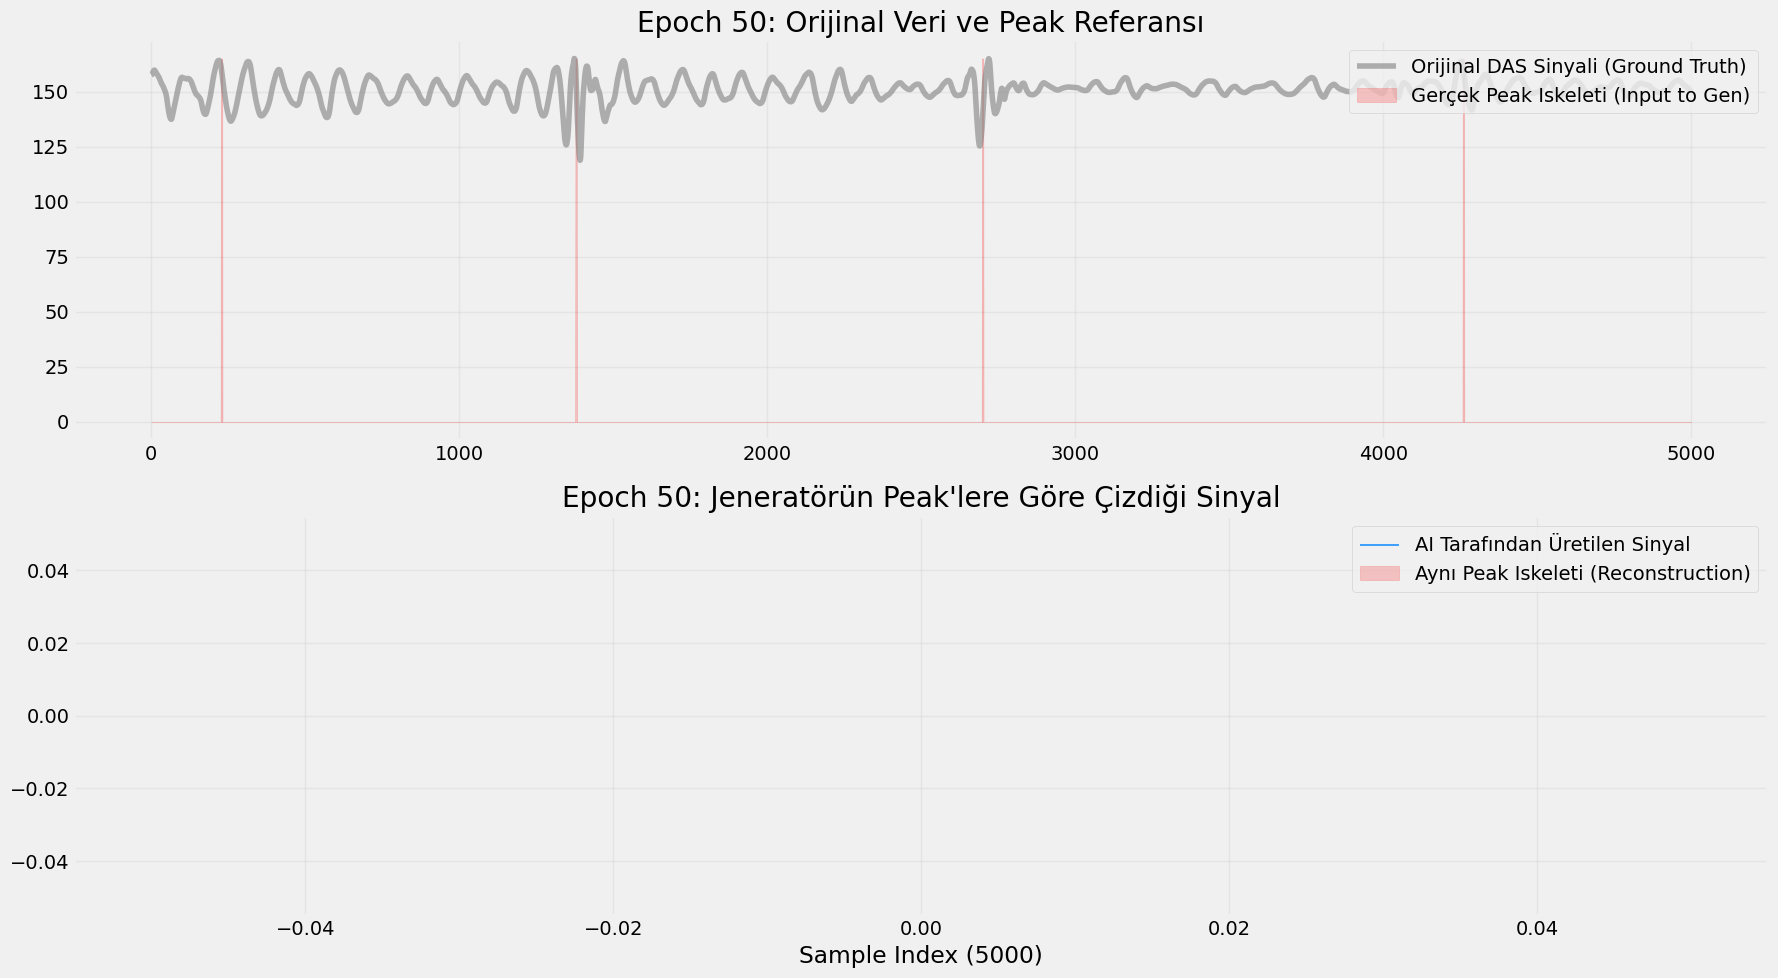

In [9]:
import time
import tensorflow as tf
EPOCHS = 50
for epoch in range(EPOCHS):
    start = time.time()
    
    epoch_d_loss = []
    epoch_g_loss = []
    
    total_steps = len(train_seq)
    print(f"--- EPOCH {epoch+1} BAŞLADI ---")
    for step in range(total_steps):
        # 1. Aşama: Veri çekiliyor mu?
        if step == 0 and epoch == 0:
            print("Veri setinden ilk batch çekiliyor...", flush=True)
            
        batch_data, _ = train_seq[step] 
        real_sigs = tf.convert_to_tensor(batch_data[:, :, 0:1], dtype=tf.float32)
        peaks = tf.convert_to_tensor(batch_data[:, :, 1:2], dtype=tf.float32)
        
        # 2. Aşama: Tracing uyarısı
        if step == 0 and epoch == 0:
            print("\n[BİLGİ] İlk step train_step'e gönderildi. TensorFlow grafiği derliyor (Tracing).")
            print("Bu işlem sistemine bağlı olarak 1-5 dakika sürebilir. Lütfen bekleyin...\n", flush=True)

        # Train step'i çalıştır
        d_l, g_l, l_rec, l_cls = train_step(real_sigs, peaks)
        
        epoch_d_loss.append(d_l)
        epoch_g_loss.append(g_l)
        
        # 3. Aşama: Çıktı basma (Her adımda anlık olarak)
        print(f"Epoch {epoch+1} | Step {step}/{total_steps} | D_Loss: {d_l:.4f} | G_Total: {g_l:.2f}", end='\r', flush=True)

    print(f"\nEpoch {epoch+1} Özet | D_Loss: {tf.reduce_mean(epoch_d_loss):.4f} | G_Total: {tf.reduce_mean(epoch_g_loss):.2f} | Rec: {l_rec:.2f} | Cls: {l_cls:.2f}", flush=True)
    
    if (epoch + 1) % 5 == 0:
        visualize_epoch_results(epoch, encoder, generator, train_seq)

In [10]:
tf.keras.backend.clear_session()

In [11]:
encoder = TimesBlock.build_encoder_v4()
generator = TimesBlock.build_generator_v4() # tanh ile
discriminator = TimesBlock.build_discriminator_v4()